# 1. Семинар. Convolution and pooling operations

<img src="https://neurohive.io/wp-content/uploads/2018/07/convolutional-neural-network.gif" width=450 height=400>

мы берём фильтр размера FxF, умножаем его на область изображения размером FxF поэлементно, складываем получившиеся поэлемнетные произведения и записываем это число в результирующий тензор


$stride$ -- это размер шага окна свёртка по осям x и y (обычно совпадают, но вполне могут быть и разными).

$padding$ -- это окружение картинки по краям нулями (или чем-то другим) для того, чтобы придать изображению после свёртки нужный размер (пэддинг делается до свёртки).

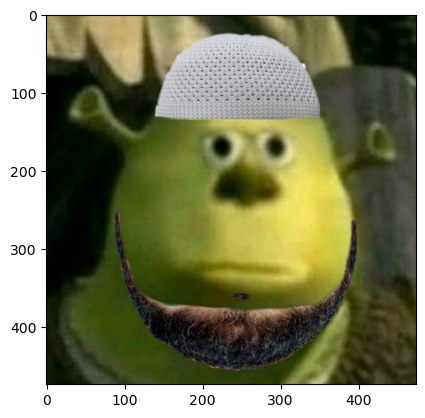

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

im = Image.open('assets/shrek.jpg')
pixels = im.load()

plt.imshow(im);

### math operations

In [2]:
from math import ceil, sqrt, floor

def norm(a):
    if a > 255:
        a = 255
    if a < 0:
        a = 0
    return a

def conv(a, b):
    sum = 0
    for i in range(len(a)):
        for j in range(len(a[0])):
            sum += a[i][j] * b[i][j]
    return sum

def median(a):
    c = []
    for i in range(len(a)):
        for j in range(len(a[0])):
            c.append(a[i][j])
    c.sort()
    return c[ceil(len(c)/2)]

def max(a):
    c = []
    for i in range(len(a)):
        for j in range(len(a[0])):
            c.append(a[i][j])
    c.sort()
    return c[len(c)-1]

def min(a):
    c = []
    for i in range(len(a)):
        for j in range(len(a[0])):
            c.append(a[i][j])
    c.sort()
    return c[0]

### convolution

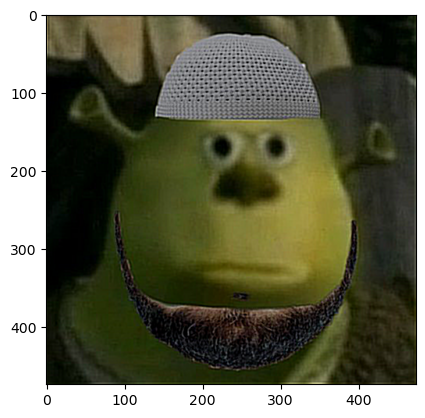

In [3]:
imFinal = im.copy()
pixels = imFinal.load()
filter = [
    [-1, -1, -1, -1, -1],
    [-1, 2, 2, 2, -1],
    [-1, 2, 8, 2, -1],
    [-1, 2, 2, 2, -1],
    [-1, -1, -1, -1, -1]
]
div = 4  
for i in range(len(filter)):
    for j in range(len(filter[0])):
        div += filter[i][j]
if div == 0:
    div = 1
for i in range(floor(len(filter)/2), im.width - floor(len(filter)/2)):
    for j in range(floor(len(filter)/2), im.height - floor(len(filter)/2)):
        matrR = []
        matrG = []
        matrB = []
        for n in range(-floor(len(filter)/2), ceil(len(filter)/2)):
            rowR = []
            rowG = []
            rowB = []
            for m in range(-floor(len(filter)/2), ceil(len(filter)/2)):
                r, g, b = pixels[i + n, j + m]
                rowR.append(r)
                rowG.append(g)
                rowB.append(b)
            matrR.append(rowR)
            matrG.append(rowG)
            matrB.append(rowB)
        r = norm(round(conv(matrR, filter) / div))
        g = norm(round(conv(matrG, filter) / div))
        b = norm(round(conv(matrB, filter) / div))
        pixels[i, j] = (r, g, b)
plt.imshow(imFinal);

### Задача 1

Вычислить размер результата после применения свёртки, $I$ -- размеры входного изображения, $f$ -- размеры фильтра:

1. Пример: $I$ = (50, 50, 3), $f$ = (3, 3), $stride$ = 1. Вычисляем:
* по ширине: 50 - 3 + 1 = 48,  
* по высоте: 50 - 3 + 1 = 48,   
то есть размер результата будет (48, 48)

2. $I$ = (1024, 768, 3), $f$=(5,5), $stride$ = 2. Вычисляем:

Из рисунка видно, что выходная ширина равна количеству нечентых чисел от 1 до 1020, т. е. 510

Аналогично по высоте получаем 382, то есть размер результата будет (510, 382).



3. $I$ = (500, 700, 5), $f$=(7,4), $stride$ = 2

Выведите общую формулу для $I$ = (H, W, C), $f$=(F, F) (фильтры обычно всё же квадратные)

In [4]:
image_h = 500
image_w = 700

f_h = 7
f_w = 4
s = 2

image_h = (image_h - f_h) // s + 1
image_w = (image_w - f_w) // s + 1

print(f'Размер после свертки: {image_h}x{image_w}')

Размер после свертки: 247x349


Теперь добавьте в получившуюся формулу $padding = p$:

In [5]:
image_h = 500
image_w = 700

f_h = 7
f_w = 4
s = 2
p = 11

image_h = (image_h + 2*p - f_h) // s + 1
image_w = (image_w + 2*p - f_w) // s + 1

print(f'Размер после свертки: {image_h}x{image_w} с padding = {p}')

Размер после свертки: 258x360 с padding = 11


## Pooling

Pooling(Пулинг) - это операция, нужная для уменьшения размерности по ширине и высоте по агрегирующим функциями

обычно используются - max и avg

пример использования max-pooling:

<img src="./W9a9n.jpg">

Если на вход подаётся изображение с несколькими каналами, то пулинг берётся по каналам, то есть если это цветная картинка HxWxC, и мы применяем к ней pooling 2x2, то получим на выходе (H // 2) x (W // 2) x C

## Полезные ссылки

1). *Примеры написания нейросетей на PyTorch (офийиальные туториалы) (на английском): https://pytorch.org/tutorials/beginner/pytorch_with_examples.html#examples  
https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html*

2). ***Один из самых подробных и полных курсов по deep learning на данный момент - это курс Стэнфордского Университета:  http://cs231n.github.io/***  

3). Практически исчерпывающая информация по основам свёрточных нейросетей (из cs231n) (на английском):  

http://cs231n.github.io/convolutional-networks/  
http://cs231n.github.io/understanding-cnn/  
http://cs231n.github.io/transfer-learning/

4). Видео о Computer Vision от Andrej Karpathy: https://www.youtube.com/watch?v=u6aEYuemt0M

# Семинар. Subclassing nn.Module

In [6]:
import torch
from torch import nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

Сгенерируем датасет Игрушка Дьявола

In [7]:
N = 100
D = 2
K = 3
X = np.zeros((N * K, D))
y = np.zeros(N * K, dtype='uint8')

for j in range(K):
    ix = range(N * j,N * (j + 1))
    r = np.linspace(0.0, 1, N)
    t = np.linspace(j * 4, (j + 1) * 4,N) + np.random.randn(N) * 0.2 # theta
    X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
    y[ix] = j

Отрисуем его

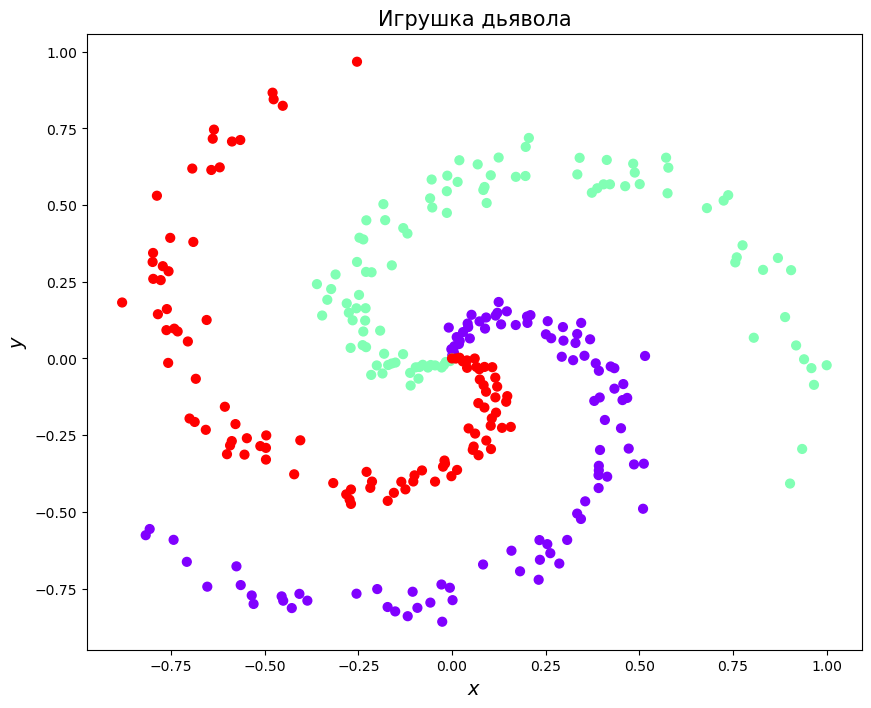

In [8]:
plt.figure(figsize=(10, 8))

plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.rainbow)

plt.title('Игрушка дьявола', fontsize=15)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.show();

In [9]:
X = torch.FloatTensor(X)
y = torch.LongTensor(y)

In [10]:
# D_in - размерность входа (X, y)
# H - размерность скрытых слоев
# D_out - размерность выходного слоя (количество классов)
D_in, H, D_out = 2, 100, 3

two_layer_net = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
    torch.nn.Softmax()
)

Используя такой метод создания сети мы ограничиваем себя в масштабируемость, поэтому принято разделять нейронную сеть на модули

In [11]:
class NN(nn.Module):
    def __init__(self):
        super().__init__() 
        self.f_lin = nn.Linear(D_in, H) # 1-ый слой
        self.s_lin = nn.Linear(H, D_out) # 2-ой слой
        
    def forward(self, X): # прямое распространение сигнала
        X = F.relu(self.f_lin(X))
        return F.softmax(self.s_lin(X))

model = NN()
loss_func = nn.CrossEntropyLoss()
optim = torch.optim.Adam(model.parameters(), 1e-1)        

Поговорим поподробнее о `softmax` и `CrossEntropyLoss`

$$softmax = \begin{pmatrix} 
\dfrac{e^{x_1}}{\sum\limits_{i=0}^{m} e^{x_i}},\; \dots,\; \dfrac{e^{x_m}}{\sum\limits_{i=0}^{m} e^{x_i}}
\end{pmatrix} $$

Таким образом, после применения softmax-функции мы получили вектор чисел из интервала $(0, 1)$, которые мы будем интерпретировать как вероятности классов.

Аналогично тому, как мы обощили сигмоиду на многоклассовый случай и получили softmax, можно обобщить и функцию потерь, получив _кросс-энтропию_:

$$CrossEntropy(x) = -\sum\limits_{i=0}^m y_i \cdot log(Softmax(x)_i), $$

где $y_i$ – истинная метка класса ($1$ если $x$ принадлежит $i$-ому классу и $0$ иначе)

C:\Users\kuzmi\AppData\Local\Temp\ipykernel_17756\1016356289.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(self.s_lin(X))


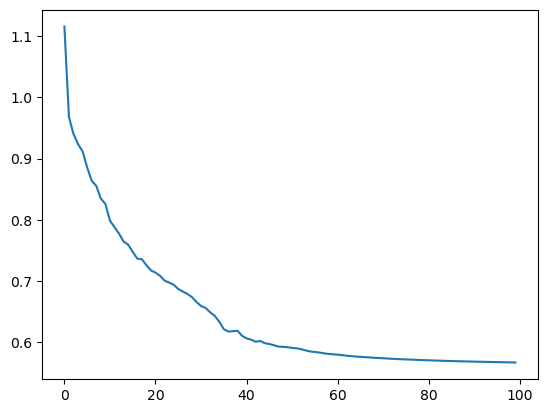

In [12]:
losses = []
for i in range(100):
    y_pred = model(X)
    loss = loss_func(y_pred, y)
    losses.append(loss.item())
    optim.zero_grad()
    loss.backward()
    optim.step()
plt.plot(losses)

Теперь посмотрим, что будет, если не положить используемые внутри слои в self

In [13]:
# Сеть без параметров

class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layers = [nn.Linear(D_in, H), nn.Linear(H, D_out)]
        self.my_useless_bias = torch.ones(1, H, requires_grad=True)
        self.more_of_my_useless_biases = [
            torch.ones(1, H, requires_grad=True),
            torch.ones(1, H, requires_grad=True),
            torch.ones(1, H, requires_grad=True)
        ]
        
    def forward(self, X):
        X = F.relu(self.linear_layers[0](X))
        X += self.my_useless_bias
        return F.softmax(self.linear_layers[1](X))
    
model = MyModule()
list(model.parameters())

[]

Как мы и ожидали параметров нет. Исправим это.

In [14]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layers = nn.ModuleList([nn.Linear(D_in, H), nn.Linear(H, D_out)])
        self.my_useless_bias = nn.Parameter(torch.ones(1, H, requires_grad=True))
        self.more_of_my_useless_biases = nn.ParameterList([
            nn.Parameter(torch.ones(1, H, requires_grad=True)),
            nn.Parameter(torch.ones(1, H, requires_grad=True)),
            nn.Parameter(torch.ones(1, H, requires_grad=True))
        ])
        
    def forward(self, X):
        X = F.relu(self.linear_layers[0](X))
        X += self.my_useless_bias
        for b in self.more_of_my_useless_biases:
            X += b
        return F.softmax(self.linear_layers[1](X))
    
model = MyModule()
list(model.parameters())

[Parameter containing:
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], requires_grad=True),
 Parameter containing:
 tensor([[ 1.9355e-02, -5.8904e-01],
         [ 5.5268e-01, -5.7475e-01],
         [ 4.0579e-01,  2.3437e-01],
         [ 6.0503e-01, -1.2165e-01],
         [ 2.3127e-01,  1.8563e-01],
         [-4.9605e-01,  2.6540e-01],
         [ 5.3687e-01,  3.2737e-01],
         [ 6.9583e-01,  6.7729e-01],
         [-5.6270e-02,  1.9495e-01],
         [-2.9932e-01,  3.1673e-01],
         [ 3.7391e-01,  4.7162e-01],
         [-2.5603e-01, -9.4669e-02],
         [-2.5608e-01, -5.8

# 3. Семинар. Свёрточные нейросети.

В этом ноутбке мы научимся писать свои свёрточные нейросети на фреймворке PyTorch, и протестируем их работу на датасетах MNIST и CIFAR10.

Рассматривается: ***задача классификации изображений***.

Свёрточные нейросети (обыкновенные, есть и намного более продвинутые) почти всегда строятся по следующему правилу:  

`INPUT -> [[CONV -> RELU]*N -> POOL?]*M -> [FC -> RELU]*K -> FC`  

то есть:  

1). ***Входной слой*** (batch картинок `RGB`)  

2). $M$ блоков (M $\ge$ 0) из свёрток и pooling-ов, причём именно в том порядке, как в формуле выше. Все эти $M$ блоков вместе называют ***feature extractor*** свёрточной нейросети, потому что эта часть сети отвечает непосредственно за формирование новых, более сложных признаков, поверх тех, которые подаются (то есть, по аналогии с MLP, мы опять же переходим к новому признаковому пространству, однако здесь оно строится сложнее, чтем в обычных многослойных сетях, поскольку используется операция свёртки)  

3). $K$ штук FullyConnected-слоёв (с активациями). Эту часть из $K$ FC-слоёв называют ***classificator***, поскольку эти слои отвечают непосредственно за предсказание нужно класса (сейчас рассматривается задача классификации изображений).

## Свёрточная нейросеть на PyTorch

Ешё раз напомним про основные компоненты нейросети:

- непосредственно, сама **архитектура** нейросети;
- начальная **инициализация** весов каждого слоя;
- метод **оптимизации** нейросети (сюда ещё входит метод изменения `learning_rate`);
- размер **батчей** (`batch_size`);
- количетсво итераций обучения (`epochs`);
- **функция потерь** (`loss`);  
- тип **регуляризации** нейросети (для каждого слоя можно свой);  

То, что связано с ***данными и задачей***:  
- само **качество** выборки (непротиворечивость, чистота, корректность постановки задачи);  
- **размер** выборки;  

Так как мы сейчас рассматриваем **архитектуру CNN**, то, помимо этих компонент, в свёрточной нейросети можно настроить следующие вещи:  

- (в каждом ConvLayer) **размер фильтров (окна свёртки)** (`kernel_size`)
- (в каждом ConvLayer) **количество фильтров** (`out_channels`)  
- (в каждом ConvLayer) размер **шага окна свёртки (stride)** (`stride`)  
- (в каждом ConvLayer) **тип padding'а** (`padding`)  


- (в каждом PoolLayer) **размер окна pooling'a** (`kernel_size`)  
- (в каждом PoolLayer) **шаг окна pooling'а** (`stride`)  
- (в каждом PoolLayer) **тип pooling'а** (`pool_type`)  
- (в каждом PoolLayer) **тип padding'а** (`padding`)

In [15]:
import torch
import torchvision
from torchvision import transforms
from torchsummary import summary
import numpy as np
import matplotlib.pyplot as plt  
%matplotlib inline

# Проверяем, доступны ли GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'

<img src="http://present5.com/presentation/20143288_415358496/image-8.jpg" width=500, height=400>

**MNIST:** это набор из 70k картинок рукописных цифр от 0 до 9, написанных людьми, 60k из которых являются тренировочной выборкой (`train` dataset)), и ещё 10k выделены для тестирования модели (`test` dataset).

In [16]:
transform = transforms.Compose(
    [transforms.ToTensor()])

trainset = torchvision.datasets.MNIST(root='./data', train=True, 
                                      download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root='./data', train=False,
                                     download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = tuple(str(i) for i in range(10))

In [17]:
trainloader.dataset.train_data.shape

D:\anaconda\Lib\site-packages\torchvision\datasets\mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


torch.Size([60000, 28, 28])

In [18]:
testloader.dataset.train_data.shape

torch.Size([10000, 28, 28])

In [19]:
trainloader.dataset.train_data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [20]:
image = trainloader.dataset.train_data[0].numpy()

In [21]:
image.shape

(28, 28)

In [22]:
plt.imshow(image, cmap = 'gray')

In [25]:
i = np.random.randint(low=0, high=60000)
plt.imshow(trainloader.dataset.train_data[i].numpy(), cmap='gray');

In [24]:
for data in trainloader:
    print(data)
    break

[tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
   

Используем Functional парадигму, потому что это удобно

In [26]:
import torch.nn as nn
import torch.nn.functional as F  # Functional

In [32]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 6, kernel_size = 5)
        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.conv2 = nn.Conv2d(in_channels = 6, out_channels = 16, kernel_size = 5)
        self.func1 = nn.Linear(4*4*16, 120)
        self.func2 = nn.Linear(120, 84)
        self.func3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 4*4*16)
        x = F.relu(self.func1(x))
        x = F.relu(self.func2(x))
        x = self.func3(x)
        return x

In [34]:
net = Model()
summary(net, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 24, 24]             156
         MaxPool2d-2            [-1, 6, 12, 12]               0
            Conv2d-3             [-1, 16, 8, 8]           2,416
         MaxPool2d-4             [-1, 16, 4, 4]               0
            Linear-5                  [-1, 120]          30,840
            Linear-6                   [-1, 84]          10,164
            Linear-7                   [-1, 10]             850
Total params: 44,426
Trainable params: 44,426
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 0.17
Estimated Total Size (MB): 0.22
----------------------------------------------------------------


In [36]:
batch = []
batch = next(iter(trainloader))
net.forward(torch.FloatTensor(batch[0]))

tensor([[ 0.0226, -0.1098, -0.1023, -0.0889, -0.0341, -0.0910,  0.0267,  0.0286,
          0.0482, -0.0174],
        [ 0.0157, -0.1144, -0.1020, -0.0943, -0.0362, -0.0992,  0.0256,  0.0361,
          0.0492, -0.0305],
        [ 0.0190, -0.1128, -0.1001, -0.1008, -0.0350, -0.0980,  0.0205,  0.0311,
          0.0470, -0.0250],
        [ 0.0170, -0.1147, -0.1023, -0.0955, -0.0332, -0.1007,  0.0261,  0.0351,
          0.0471, -0.0311]], grad_fn=<AddmmBackward0>)

## Обучение CNN

In [44]:
from tqdm import tqdm_notebook

In [38]:
net = Model().to(device)

In [51]:
loss_fc = torch.nn.CrossEntropyLoss()
learning_rate = 1e-4
optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)
losses = []

C:\Users\kuzmi\AppData\Local\Temp\ipykernel_17756\3059689195.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for epoch in tqdm_notebook(range(2)):


  0%|          | 0/2 [00:00<?, ?it/s]

C:\Users\kuzmi\AppData\Local\Temp\ipykernel_17756\3059689195.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i, batch in enumerate(tqdm_notebook(trainloader)):


  0%|          | 0/15000 [00:00<?, ?it/s]

[1,  2000] loss: 0.092
[1,  4000] loss: 0.091
[1,  6000] loss: 0.087
[1,  8000] loss: 0.087
[1, 10000] loss: 0.076
[1, 12000] loss: 0.074
[1, 14000] loss: 0.076


  0%|          | 0/15000 [00:00<?, ?it/s]

[2,  2000] loss: 0.071
[2,  4000] loss: 0.068
[2,  6000] loss: 0.068
[2,  8000] loss: 0.066
[2, 10000] loss: 0.070
[2, 12000] loss: 0.061
[2, 14000] loss: 0.056


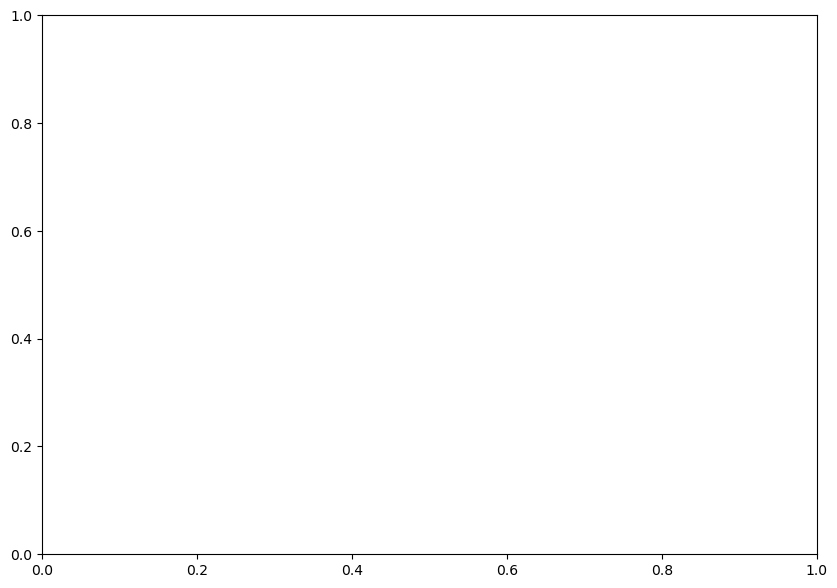

In [55]:
fig = plt.figure(figsize = (10, 7))
ax = fig.add_subplot(1, 1, 1)

for epoch in tqdm_notebook(range(2)):
    run_loss = 0.0
    for i, batch in enumerate(tqdm_notebook(trainloader)):
        X_batch, y_batch = batch
        optimizer.zero_grad()
        y_pred = net(X_batch.to(device))
        loss = loss_fc(y_pred, y_batch.to(device))
        loss.backward()
        optimizer.step()
        run_loss += loss.item()
        if i % 2000 == 1999:
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, run_loss / 2000))
            losses.append(run_loss)
            run_loss = 0.0
plt.show()

In [56]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

with torch.no_grad():
    for data in testloader:
        images, labels = data
        y_pred = net(images.to(device))
        _, predicted = torch.max(y_pred, 1)
        
        c = (predicted.cpu().detach() == labels)
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1
            
for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of     0 : 99 %
Accuracy of     1 : 99 %
Accuracy of     2 : 99 %
Accuracy of     3 : 98 %
Accuracy of     4 : 97 %
Accuracy of     5 : 98 %
Accuracy of     6 : 98 %
Accuracy of     7 : 97 %
Accuracy of     8 : 97 %
Accuracy of     9 : 97 %


## Задача 1 

Протестируйте эту нейросеть на отдельных картинках из тестового датасета: напишите функцию, которая принимает индекс картинки в тестовом датасете, отрисовывает её, потом запускает на ней модель (нейросеть) и выводит результат предсказания.

In [59]:
net

Model(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (func1): Linear(in_features=256, out_features=120, bias=True)
  (func2): Linear(in_features=120, out_features=84, bias=True)
  (func3): Linear(in_features=84, out_features=10, bias=True)
)

In [78]:
def test_prediction(index):
    image, label = testloader.dataset[index]
    with torch.no_grad():
        y_pred = net(image.to(device))
        predicted = torch.max(y_pred, 1)
        print(image.shape, '\n')
    print(f'Predicted: {predicted}, Actual: {label}')

test_prediction(0)

torch.Size([1, 28, 28]) 

Predicted: torch.return_types.max(
values=tensor([9.2150]),
indices=tensor([7])), Actual: 7
